<a href="https://colab.research.google.com/github/hariniganesan31/Code-Alpha-Data-Science/blob/main/Unemployment_Analysis_with_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install kagglehub pandas matplotlib seaborn

In [3]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [4]:
import kagglehub
path = kagglehub.dataset_download("gokulrajkmv/unemployment-in-india")
print("Path to dataset files:", path)
print("Files in the dataset folder:", os.listdir(path))

Using Colab cache for faster access to the 'unemployment-in-india' dataset.
Path to dataset files: /kaggle/input/unemployment-in-india
Files in the dataset folder: ['Unemployment_Rate_upto_11_2020.csv', 'Unemployment in India.csv']


In [5]:
file_path = os.path.join(path, "Unemployment_Rate_upto_11_2020.csv")

data = pd.read_csv(file_path)

print(data.head())

           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-01-2020          M                              5.48   
1  Andhra Pradesh   29-02-2020          M                              5.83   
2  Andhra Pradesh   31-03-2020          M                              5.79   
3  Andhra Pradesh   30-04-2020          M                             20.51   
4  Andhra Pradesh   31-05-2020          M                             17.43   

    Estimated Employed   Estimated Labour Participation Rate (%) Region.1  \
0             16635535                                     41.02    South   
1             16545652                                     40.90    South   
2             15881197                                     39.18    South   
3             11336911                                     33.10    South   
4             12988845                                     36.46    South   

   longitude  latitude  
0    15.9129     79.74  
1    15.9129

In [6]:
print(data.columns)

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='object')


In [7]:
data.columns = data.columns.str.strip()

print(data.columns)
print(data.isnull().sum())

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='object')
Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Region.1                                   0
longitude                                  0
latitude                                   0
dtype: int64


In [8]:
data = data.dropna()

print("Dataset shape after cleaning:", data.shape)

Dataset shape after cleaning: (267, 9)


In [9]:
data = data.rename(columns={
    "Region": "Region",
    "Date": "Date",
    "Frequency": "Frequency",
    "Estimated Unemployment Rate (%)": "Unemployment_Rate",
    "Estimated Employed": "Employed",
    "Estimated Labour Participation Rate (%)": "Labour_Participation_Rate",
    "Region.1": "Area",
    "longitude": "Longitude",
    "latitude": "Latitude"
})

print(data.head())

           Region         Date Frequency  Unemployment_Rate  Employed  \
0  Andhra Pradesh   31-01-2020         M               5.48  16635535   
1  Andhra Pradesh   29-02-2020         M               5.83  16545652   
2  Andhra Pradesh   31-03-2020         M               5.79  15881197   
3  Andhra Pradesh   30-04-2020         M              20.51  11336911   
4  Andhra Pradesh   31-05-2020         M              17.43  12988845   

   Labour_Participation_Rate   Area  Longitude  Latitude  
0                      41.02  South    15.9129     79.74  
1                      40.90  South    15.9129     79.74  
2                      39.18  South    15.9129     79.74  
3                      33.10  South    15.9129     79.74  
4                      36.46  South    15.9129     79.74  


In [10]:
data["Date"] = pd.to_datetime(data["Date"])

data["Month"] = data["Date"].dt.month_name()
data["Year"] = data["Date"].dt.year

print(data[["Date", "Month", "Year"]].head())

        Date     Month  Year
0 2020-01-31   January  2020
1 2020-02-29  February  2020
2 2020-03-31     March  2020
3 2020-04-30     April  2020
4 2020-05-31       May  2020


/tmp/ipykernel_1582/2768850010.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data["Date"] = pd.to_datetime(data["Date"])


In [11]:
print("Dataset Information:")
print(data.info())

print("\nUnemployment Rate Statistics:")
print(data["Unemployment_Rate"].describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Region                     267 non-null    object        
 1   Date                       267 non-null    datetime64[ns]
 2   Frequency                  267 non-null    object        
 3   Unemployment_Rate          267 non-null    float64       
 4   Employed                   267 non-null    int64         
 5   Labour_Participation_Rate  267 non-null    float64       
 6   Area                       267 non-null    object        
 7   Longitude                  267 non-null    float64       
 8   Latitude                   267 non-null    float64       
 9   Month                      267 non-null    object        
 10  Year                       267 non-null    int32         
dtypes: datetime64[ns](1), float64(4), int32(1), int64(

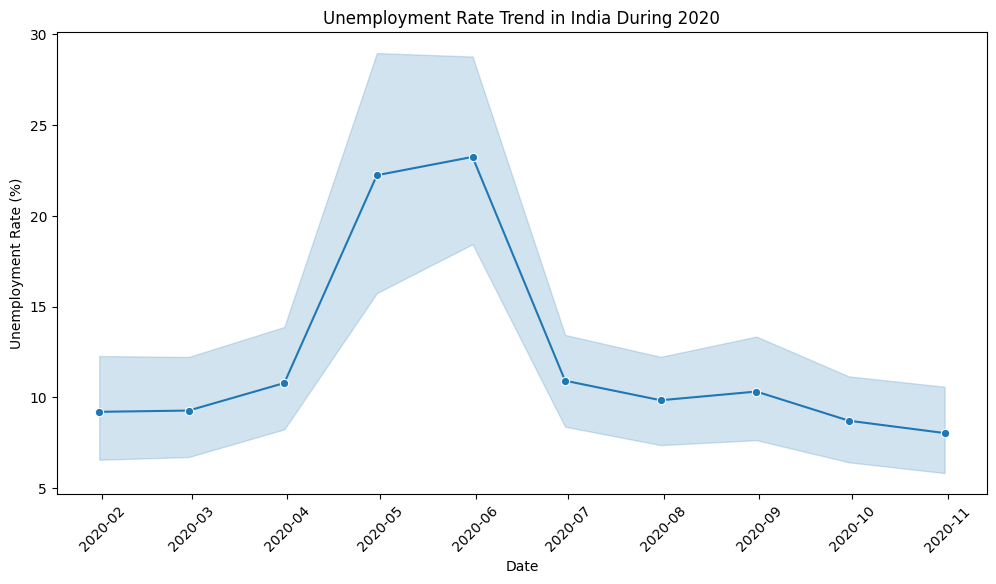

In [12]:
plt.figure(figsize=(12, 6))

sns.lineplot(data=data, x="Date", y="Unemployment_Rate", marker="o")

plt.title("Unemployment Rate Trend in India During 2020")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.show()

In [13]:
region_unemployment = data.groupby("Region")["Unemployment_Rate"].mean().sort_values(ascending=False)

print(region_unemployment)

Region
Haryana             27.477000
Tripura             25.055000
Jharkhand           19.539000
Bihar               19.471000
Delhi               18.414000
Puducherry          17.942000
Jammu & Kashmir     16.477778
Himachal Pradesh    16.065000
Rajasthan           15.868000
Tamil Nadu          12.187000
Goa                 12.167000
Punjab              11.981000
Uttarakhand         11.156000
West Bengal         10.192000
Sikkim               9.792500
Uttar Pradesh        9.737000
Kerala               9.434000
Andhra Pradesh       8.664000
Maharashtra          7.979000
Chhattisgarh         7.819000
Karnataka            7.668000
Madhya Pradesh       6.854000
Telangana            6.833000
Odisha               6.462000
Gujarat              6.376000
Assam                4.856000
Meghalaya            3.866000
Name: Unemployment_Rate, dtype: float64


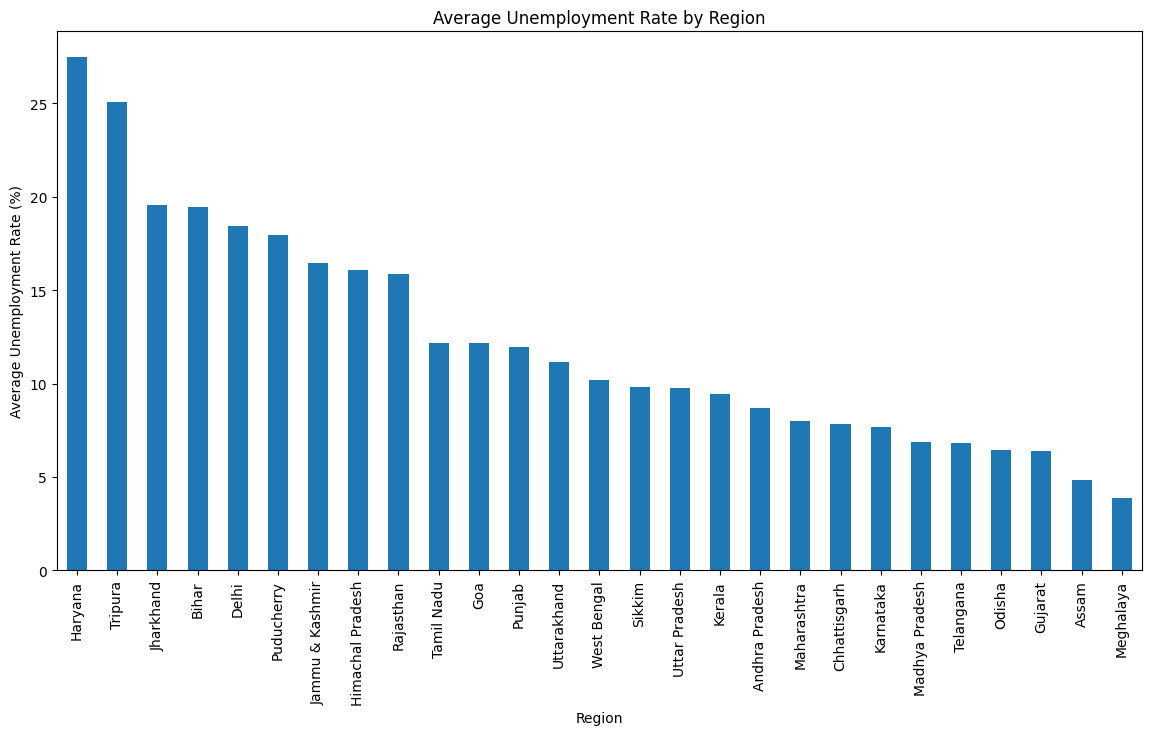

In [14]:
plt.figure(figsize=(14, 7))

region_unemployment.plot(kind="bar")

plt.title("Average Unemployment Rate by Region")
plt.xlabel("Region")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=90)
plt.show()

In [15]:
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

monthly_unemployment = (
    data.groupby("Month")["Unemployment_Rate"]
    .mean()
    .reindex(month_order)
)

print(monthly_unemployment)

Month
January       9.196538
February      9.266154
March        10.782593
April        22.236154
May          23.244444
June         10.911111
July          9.834444
August       10.313333
September     8.705926
October       8.026296
November           NaN
December           NaN
Name: Unemployment_Rate, dtype: float64


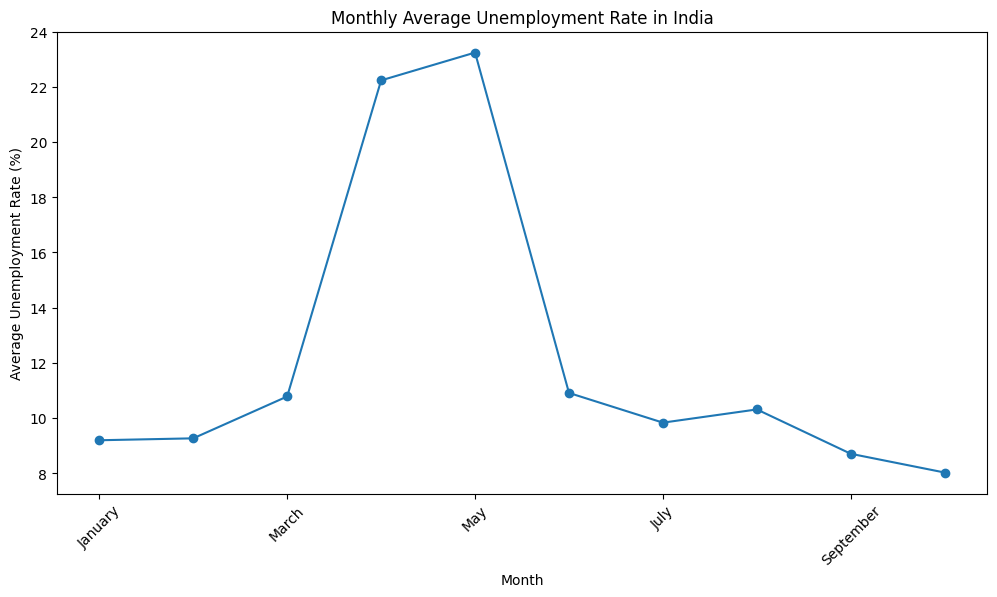

In [16]:
plt.figure(figsize=(12, 6))

monthly_unemployment.plot(kind="line", marker="o")

plt.title("Monthly Average Unemployment Rate in India")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.show()

In [17]:
before_covid = data[data["Date"] < "2020-03-01"]["Unemployment_Rate"].mean()

during_covid = data[
    (data["Date"] >= "2020-03-01") &
    (data["Date"] <= "2020-11-30")
]["Unemployment_Rate"].mean()

print("Average unemployment rate before Covid-19:", round(before_covid, 2), "%")
print("Average unemployment rate during Covid-19:", round(during_covid, 2), "%")

Average unemployment rate before Covid-19: 9.23 %
Average unemployment rate during Covid-19: 12.96 %


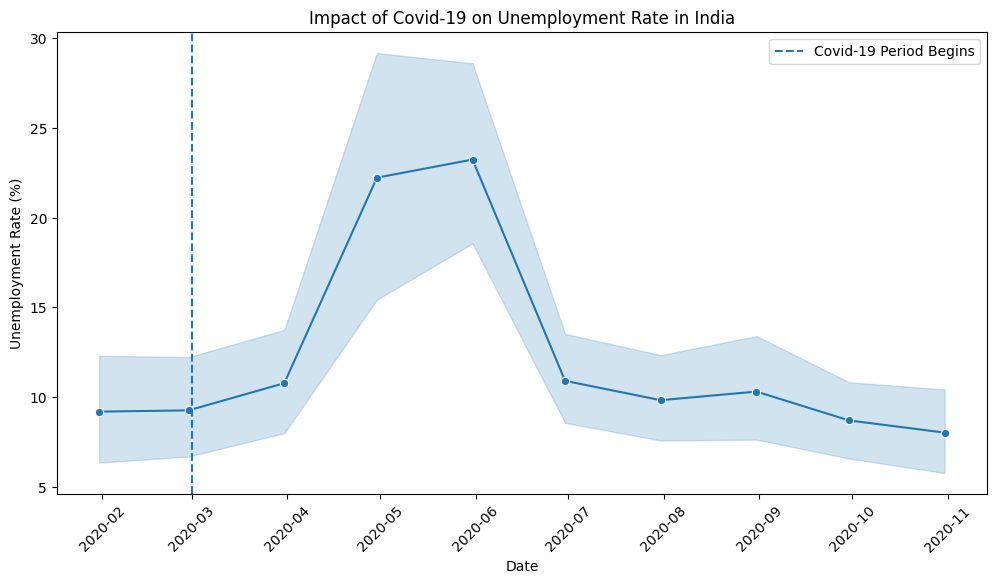

In [18]:
plt.figure(figsize=(12, 6))

sns.lineplot(data=data, x="Date", y="Unemployment_Rate", marker="o")

plt.axvline(
    pd.Timestamp("2020-03-01"),
    linestyle="--",
    label="Covid-19 Period Begins"
)

plt.title("Impact of Covid-19 on Unemployment Rate in India")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [19]:
print("FINAL INSIGHTS")
print("1. Unemployment rate increased significantly during the Covid-19 lockdown period.")
print("2. The highest unemployment levels were generally observed during April and May 2020.")
print("3. Unemployment rates differed across regions, showing the need for region-specific policies.")
print("4. Government employment schemes, skill development programs, and social security support can help reduce unemployment.")

FINAL INSIGHTS
1. Unemployment rate increased significantly during the Covid-19 lockdown period.
2. The highest unemployment levels were generally observed during April and May 2020.
3. Unemployment rates differed across regions, showing the need for region-specific policies.
4. Government employment schemes, skill development programs, and social security support can help reduce unemployment.
